In [259]:
"""
Shared Data Pipeline
====================
Shared data loading and preprocessing functions used across all models.
Put your common data cleaning, feature engineering, and splitting logic here.

Usage from any model:
    import sys
    sys.path.insert(0, str(Path(__file__).resolve().parents[1]))
    from pipelines.data_pipeline import load_raw_data, preprocess, split_data
"""
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

In [260]:
"""
Smart City Data Preprocessing Hints
=====================================
These are HINTS, not complete solutions. Use them as a starting point
for your data pipeline. You'll need to adapt and expand these for your
specific models.

Datasets:
- city_traffic_accidents.csv (~500K accident records)
- pothole_images/ (~4,400 road surface images)
- urbanpulse_311_complaints.csv (~500K complaint records)
"""

# =============================================================================
# *** CLASS IMBALANCE WARNING ***
# =============================================================================
# EVERY dataset in this project has class imbalance. If you ignore it,
# your model will learn to predict the majority class and look "accurate"
# while being clinically useless.
#
# Techniques you MUST consider for every model:
#   1. class_weight='balanced' in sklearn models (easiest first step)
#   2. SMOTE (Synthetic Minority Oversampling) from imblearn
#   3. Stratified train/test splits (use stratify= in train_test_split)
#   4. Weighted loss functions in TensorFlow/Keras
#   5. Evaluation with weighted F1, precision, recall — NOT just accuracy
#
# A model that predicts the majority class for everything is WORTHLESS
# even if it gets 80%+ accuracy. Always check per-class metrics.
# =============================================================================


"\nSmart City Data Preprocessing Hints\n=====================================\nThese are HINTS, not complete solutions. Use them as a starting point\nfor your data pipeline. You'll need to adapt and expand these for your\nspecific models.\n\nDatasets:\n- city_traffic_accidents.csv (~500K accident records)\n- pothole_images/ (~4,400 road surface images)\n- urbanpulse_311_complaints.csv (~500K complaint records)\n"

In [261]:
#import sys
#sys.path.insert(0, str(Path(__file__).resolve().parents[1]))

from pathlib import Path
import sys

project_root = Path.cwd().parent  # or adjust levels
sys.path.insert(0, str(project_root))

In [262]:


# Project paths
PROJECT_ROOT = project_root #Path(__file__).resolve().parents[1]
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"

In [263]:
#print(project_root)
#print(PROJECT_ROOT)
print(RAW_DATA_DIR)

C:\Git_Repo\final-capstone-e2ws-ai-topia-consulting\data\raw


In [321]:
filepath = RAW_DATA_DIR / "city_traffic_accidents.csv"
df = pd.read_csv(filepath)




In [322]:
# End_Lat and End_Lng are duplicating Start_Lat and Start_Lng
# remove them to avoid causing model to bias towards these features 

df.drop(columns=['Street', 'ID', 'Source', 'Description', 'Country', 'End_Lat', 'End_Lng'], inplace=True)

for col in df.columns:
    print (col)

Severity
Start_Time
End_Time
Start_Lat
Start_Lng
Distance(mi)
City
County
State
Zipcode
Timezone
Airport_Code
Weather_Timestamp
Temperature(F)
Wind_Chill(F)
Humidity(%)
Pressure(in)
Visibility(mi)
Wind_Direction
Wind_Speed(mph)
Precipitation(in)
Weather_Condition
Amenity
Bump
Crossing
Give_Way
Junction
No_Exit
Railway
Roundabout
Station
Stop
Traffic_Calming
Traffic_Signal
Turning_Loop
Sunrise_Sunset
Civil_Twilight
Nautical_Twilight
Astronomical_Twilight


In [323]:
# cleaning - change all text to lower case

df = df.apply(lambda x: x.str.lower() if x.dtype == 'object' else x)


In [324]:
    # Parse datetime columns
df['Start_Time'] = pd.to_datetime(df['Start_Time'], errors='coerce')
df['End_Time'] = pd.to_datetime(df['End_Time'], errors='coerce')
df['Weather_Timestamp'] = pd.to_datetime(df['Weather_Timestamp'], errors='coerce')

In [325]:
# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
#print(f"\nColumn names:")
#print(df.columns.tolist())

Dataset shape: 500,000 rows, 39 columns


### Model 1: Traffic Accident Severity — Traditional ML

- Multi-class classification: predict accident severity (1-4 scale)
- This dataset has significant class imbalance — your approach to handling it will be a key evaluation criterion. **Weighted F1 is the real evaluation metric**, not accuracy.
- Use classical ML algorithms (XGBoost, Random Forest, Gradient Boosting, etc.)
- Must be interpretable — city planners need to understand WHY an intersection is flagged as high-risk
- **Minimum Benchmark:** Accuracy > 70%, weighted F1 > 0.55
- **Stretch Goal:** Accuracy > 80%, weighted F1 > 0.70
- **Required:** SHAP or feature importance analysis — which factors most predict severe accidents?

In [326]:
# This is a classification problem, we need to convert Severity to integer
df['Target'] = df['Severity'].astype(int) 

In [327]:
# Define your target variable
TARGET = 'Target'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: Target

Basic Statistics:
count    500000.000000
mean          2.212386
std           0.487531
min           1.000000
25%           2.000000
50%           2.000000
75%           2.000000
max           4.000000
Name: Target, dtype: float64


In [328]:
df['Target'].value_counts()

Target
2    398335
3     84063
4     13244
1      4358
Name: count, dtype: int64

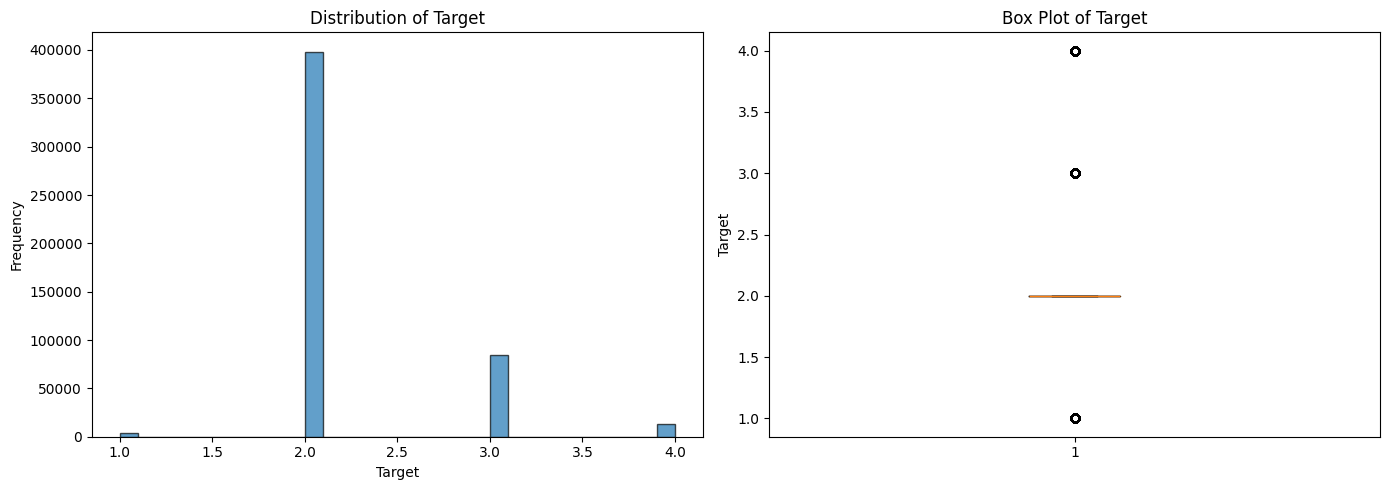


Skewness: 1.81
→ Target is highly skewed. Consider log transform in feature engineering.


In [329]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

In [330]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"
#keep a copy of original data before making changes
df_clean = df.drop_duplicates()
df = df_clean

# YOUR CODE HERE:
duplicate_rows = df[df.duplicated()]
pct_duplicated = len(duplicate_rows)/len(df)
print(f"Duplicated rows: {len(duplicate_rows):,}, ({pct_duplicated:.2%})")

Duplicated rows: 0, (0.00%)


Use Zipcode to lookup Airport code

In [331]:
lookup_file_path = RAW_DATA_DIR / "zip_to_airport_lookup.csv"
lookup = pd.read_csv(lookup_file_path, dtype=str)
lookup_dict = dict(zip(lookup["zip_code"], lookup["nearest_airport_iata"]))

ac_mask = df['Airport_Code'].isna()

df_zipcode = df[['Zipcode', 'Airport_Code']].loc[ac_mask]
print(df_zipcode.shape)

df_zipcode['Airport_Code'] = 'k'+df_zipcode['Zipcode'].map(lookup_dict).str.lower()

(1505, 2)


In [332]:
print(df_zipcode)

       Zipcode Airport_Code
173      86015         kflg
471      10922         kswf
669        NaN          NaN
924      23803         kptb
1060     10922         kswf
...        ...          ...
497190   85190          NaN
497391   23669         klfi
497762   29486         kchs
498580   23503         kngu
499038   23602         kphf

[1505 rows x 2 columns]


In [333]:
df_clean = df.copy()
df_new = df_zipcode.copy()

update_dict = dict(zip(df_new["Zipcode"], df_new["Airport_Code"]))

df_clean["Airport_Code"] = df_clean["Zipcode"].map(update_dict).combine_first(df_clean["Airport_Code"])

In [334]:
df = df_clean.copy()

**CHECKPOINT** - 03.21.2026

In [335]:
median_time_elapsed = (df['End_Time'] - df['Start_Time']).median()

In [336]:
df.fillna({'Start_Time': df['Start_Time'].median()}, inplace=True)

In [337]:
df.fillna({'End_Time': df['Start_Time']+median_time_elapsed}, inplace=True)

In [338]:
df.fillna({'Precipitation(in)': df['Precipitation(in)'].median()}, inplace=True)

In [339]:
df.fillna({'Wind_Chill(F)': df['Wind_Chill(F)'].median()}, inplace=True)

In [340]:
df.fillna({'Wind_Speed(mph)': df['Wind_Speed(mph)'].median(),
           'Visibility(mi)': df['Visibility(mi)'].median(),
           'Humidity(%)': df['Humidity(%)'].median()}, inplace=True)

In [341]:
df.fillna({'Temperature(F)': df['Temperature(F)'].median(),
           'Pressure(in)': df['Pressure(in)'].median(),
           'Weather_Timestamp': df['Weather_Timestamp'].median()}, inplace=True)

In [342]:
# for categorical columns, fillna with 'Missing' to preserve the fact that data is missing

df.fillna({'Wind_Direction': 'missing',
           'Weather_Condition': 'missing',
           'Civil_Twilight': 'missing',
           'Nautical_Twilight': 'missing',
           'Astronomical_Twilight': 'missing',
           'Sunrise_Sunset': 'missing',
           'City': 'missing',
           'Zipcode': 'missing',
           'Airport_Code': 'missing',
           'Timezone': 'missing'
          }, inplace=True)

In [344]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:
missing_cnt = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_cnt,
    'Missing %': missing_pct
})

# 4. Filter to display only columns that have missing values (Count > 0)
#    and sort by 'Missing %' in descending order
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by='Missing %', ascending=False)

# 5. Display the result
#print(missing_df)

In [345]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_df[missing_df['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

✓ No missing values in the dataset!


In [346]:



# =============================================================================
# HINT 2: Temporal Feature Engineering
# =============================================================================

def create_temporal_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Time patterns are among the strongest predictors of accident severity.

    Features to extract:
    - Hour of day (rush hour vs. off-peak)
    - Day of week (weekday vs. weekend)
    - Month (seasonal patterns — winter ice, summer heat)
    - Duration of traffic impact
    - Is it dark? (Sunrise_Sunset column helps, but you can derive from time too)
    """
    df['hour'] = df['Start_Time'].dt.hour
    df['day_of_week'] = df['Start_Time'].dt.dayofweek
    df['month'] = df['Start_Time'].dt.month
    df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

    # Rush hour flags
    df['is_morning_rush'] = df['hour'].between(7, 9).astype(int)
    df['is_evening_rush'] = df['hour'].between(16, 19).astype(int)
    df['is_rush_hour'] = (df['is_morning_rush'] | df['is_evening_rush']).astype(int)

    # Duration of traffic impact (in minutes)
    if 'End_Time' in df.columns:
        df['duration_min'] = (df['End_Time'] - df['Start_Time']).dt.total_seconds() / 60
        # Cap extreme values
        df['duration_min'] = df['duration_min'].clip(0, 1440)  # Max 24 hours

    return df

In [347]:
df_clean = df.copy()

df = create_temporal_features(df_clean)



In [348]:



def categorize_weather(condition) -> str:
    """Group detailed weather conditions into broader categories."""
    if pd.isna(condition):
        return 'unknown'

    condition = str(condition).lower()

    if any(w in condition for w in ['clear', 'fair']):
        return 'clear'
    elif any(w in condition for w in ['cloud', 'overcast']):
        return 'cloudy'
    elif any(w in condition for w in ['rain', 'drizzle', 'shower']):
        return 'rain'
    elif any(w in condition for w in ['snow', 'sleet', 'ice', 'wintry']):
        return 'snow_ice'
    elif any(w in condition for w in ['fog', 'mist', 'haze', 'smoke']):
        return 'low_visibility'
    elif any(w in condition for w in ['thunder', 'storm']):
        return 'storm'
    else:
        return 'other'


# =============================================================================
# HINT 3: Weather Feature Processing
# =============================================================================

def process_weather_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Weather is a major factor in accident severity.

    Missing values in weather columns are NOT random — they often mean:
    - Weather station was offline
    - Data wasn't available at the time of the accident
    - The weather API didn't return data for that location

    Strategy: Create a "weather_data_available" flag, then impute or drop.

    Key weather features:
    - Temperature(F): Freezing conditions are dangerous
    - Visibility(mi): Low visibility = more severe accidents
    - Precipitation(in): Rain/snow increases severity
    - Weather_Condition: Categorical (Clear, Rain, Snow, Fog, etc.)
    """
    weather_cols = ['Temperature(F)', 'Humidity(%)', 'Pressure(in)',
                    'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)']

    # Flag for whether weather data is available
    # df['weather_data_available'] = df[weather_cols].notna().all(axis=1).astype(int)

    # Freezing conditions
    if 'Temperature(F)' in df.columns:
        df['is_freezing'] = (df['Temperature(F)'] <= 32).astype(int)

    # Low visibility
    if 'Visibility(mi)' in df.columns:
        df['low_visibility'] = (df['Visibility(mi)'] < 2).astype(int)

    # Group weather conditions
    if 'Weather_Condition' in df.columns:
        df['weather_group'] = df['Weather_Condition'].apply(categorize_weather)

    return df

In [349]:
df_clean = df.copy()

df = process_weather_features(df_clean)

In [350]:
print(df.shape)

(499290, 51)


In [351]:
df.columns

Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'City', 'County', 'State', 'Zipcode', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Target', 'hour', 'day_of_week', 'month',
       'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour',
       'duration_min', 'is_freezing', 'low_visibility', 'weather_group'],
      dtype='object')

In [352]:
# =============================================================================
# HINT 10: Geographic Feature Engineering
# =============================================================================

def create_geographic_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Location matters for accident severity prediction.

    Feature ideas:
    1. State-level patterns (some states have more severe accidents)
    2. Urban vs. rural (can infer from city population or zip code)
    3. Latitude as a proxy for climate (northern = more ice/snow)
    4. Distance from nearest airport (proxy for traffic volume)
    5. Cluster analysis on lat/lng to find accident hotspots

    Warning: Don't use raw lat/lng as features — they're too specific
    and lead to overfitting. Instead, bin them or use for clustering.
    """
    # State-level average severity (target encoding — be careful of leakage!)
    # Only compute on training data, then apply to test

    # Latitude bins (rough climate proxy)
    if 'Start_Lat' in df.columns:
        df['lat_bin'] = pd.cut(df['Start_Lat'], bins=10, labels=False)

    return df

In [353]:
df_clean = df.copy()

df = create_geographic_features(df_clean)

print(df.shape)
print(df.columns)

(499290, 52)
Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'City', 'County', 'State', 'Zipcode', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Target', 'hour', 'day_of_week', 'month',
       'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour',
       'duration_min', 'is_freezing', 'low_visibility', 'weather_group',
       'lat_bin'],
      dtype='object')


In [354]:

# =============================================================================
# HINT 4: Road Feature Processing
# =============================================================================

def process_road_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    The dataset has 13 boolean road feature columns.

    These are already binary (True/False) and very useful for ML models.
    Consider creating aggregate features:
    - total_road_features: count of road features at the accident location
    - has_traffic_control: any of traffic signal, stop, give way, etc.
    """
    road_features = ['Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction',
                     'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop',
                     'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop']

    existing = [f for f in road_features if f in df.columns]

    # Total road features present
    df['n_road_features'] = df[existing].sum(axis=1)

    # Traffic control present
    control_features = ['Traffic_Signal', 'Stop', 'Give_Way', 'Traffic_Calming']
    existing_control = [f for f in control_features if f in df.columns]
    df['has_traffic_control'] = df[existing_control].any(axis=1).astype(int)

    return df

In [355]:
df_clean = df.copy()

df = process_road_features(df_clean)

print(df.shape)
print(df.columns)

(499290, 54)
Index(['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng',
       'Distance(mi)', 'City', 'County', 'State', 'Zipcode', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight', 'Target', 'hour', 'day_of_week', 'month',
       'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour',
       'duration_min', 'is_freezing', 'low_visibility', 'weather_group',
       'lat_bin', 'n_road_features', 'has_traffic_control'],
      dtype='object')


In [356]:
# =============================================================================
# HINT 5: Handling Severity Class Imbalance
# =============================================================================

def analyze_severity_distribution(df: pd.DataFrame):
    """
    Severity distribution is heavily imbalanced:
    - Severity 1: ~1-2% (very rare)
    - Severity 2: ~80% (dominant — this is your biggest challenge)
    - Severity 3: ~12-15%
    - Severity 4: ~5-8%

    This is a MAJOR challenge. If you just predict class 2 for everything,
    you'll get ~80% accuracy but your model is COMPLETELY USELESS.
    Weighted F1 is the real evaluation metric, not accuracy.

    Strategies:
    1. Class weights: Give higher weight to minority classes
       - sklearn: class_weight='balanced'
       - TensorFlow/Keras: class_weight parameter in model.fit()
    2. SMOTE or oversampling for minority classes
    3. Undersampling the majority class (Severity 2)
    4. Consider binary: "severe" (3-4) vs "not severe" (1-2)
    5. Focal loss — designed for class imbalance

    For evaluation: Use weighted F1, not just accuracy.
    Weighted F1 accounts for class imbalance by weighting each class by its support.
    """
    print("Severity Distribution:")
    print(df['Severity'].value_counts().sort_index())
    print(f"\nClass ratios:")
    print(df['Severity'].value_counts(normalize=True).sort_index().round(3))

In [357]:
analyze_severity_distribution(df)

Severity Distribution:
Severity
1      4353
2    397669
3     84039
4     13229
Name: count, dtype: int64

Class ratios:
Severity
1    0.009
2    0.796
3    0.168
4    0.026
Name: proportion, dtype: float64


EDA - 
create histogram between lat_bin and 'Target'

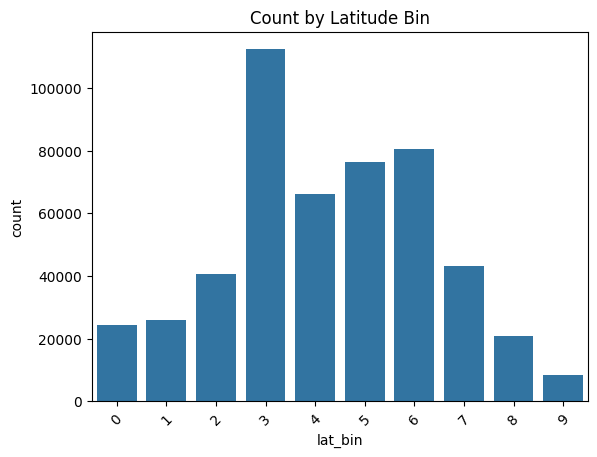

In [358]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x="lat_bin")

plt.xticks(rotation=45)
plt.title("Count by Latitude Bin")
plt.show()

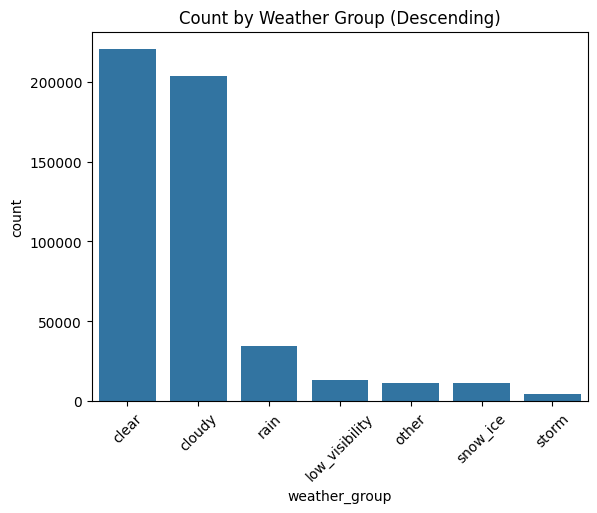

In [359]:
order = df["weather_group"].value_counts().index

sns.countplot(data=df, x="weather_group", order = order)

plt.xticks(rotation=45)
plt.title("Count by Weather Group (Descending)")
plt.show()

There are 23 numberical columns. They are ['Start_Lat', 'Start_Lng', 'Distance(mi)', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'duration_min', 'is_freezing', 'low_visibility', 'lat_bin', 'n_road_features', 'has_traffic_control']


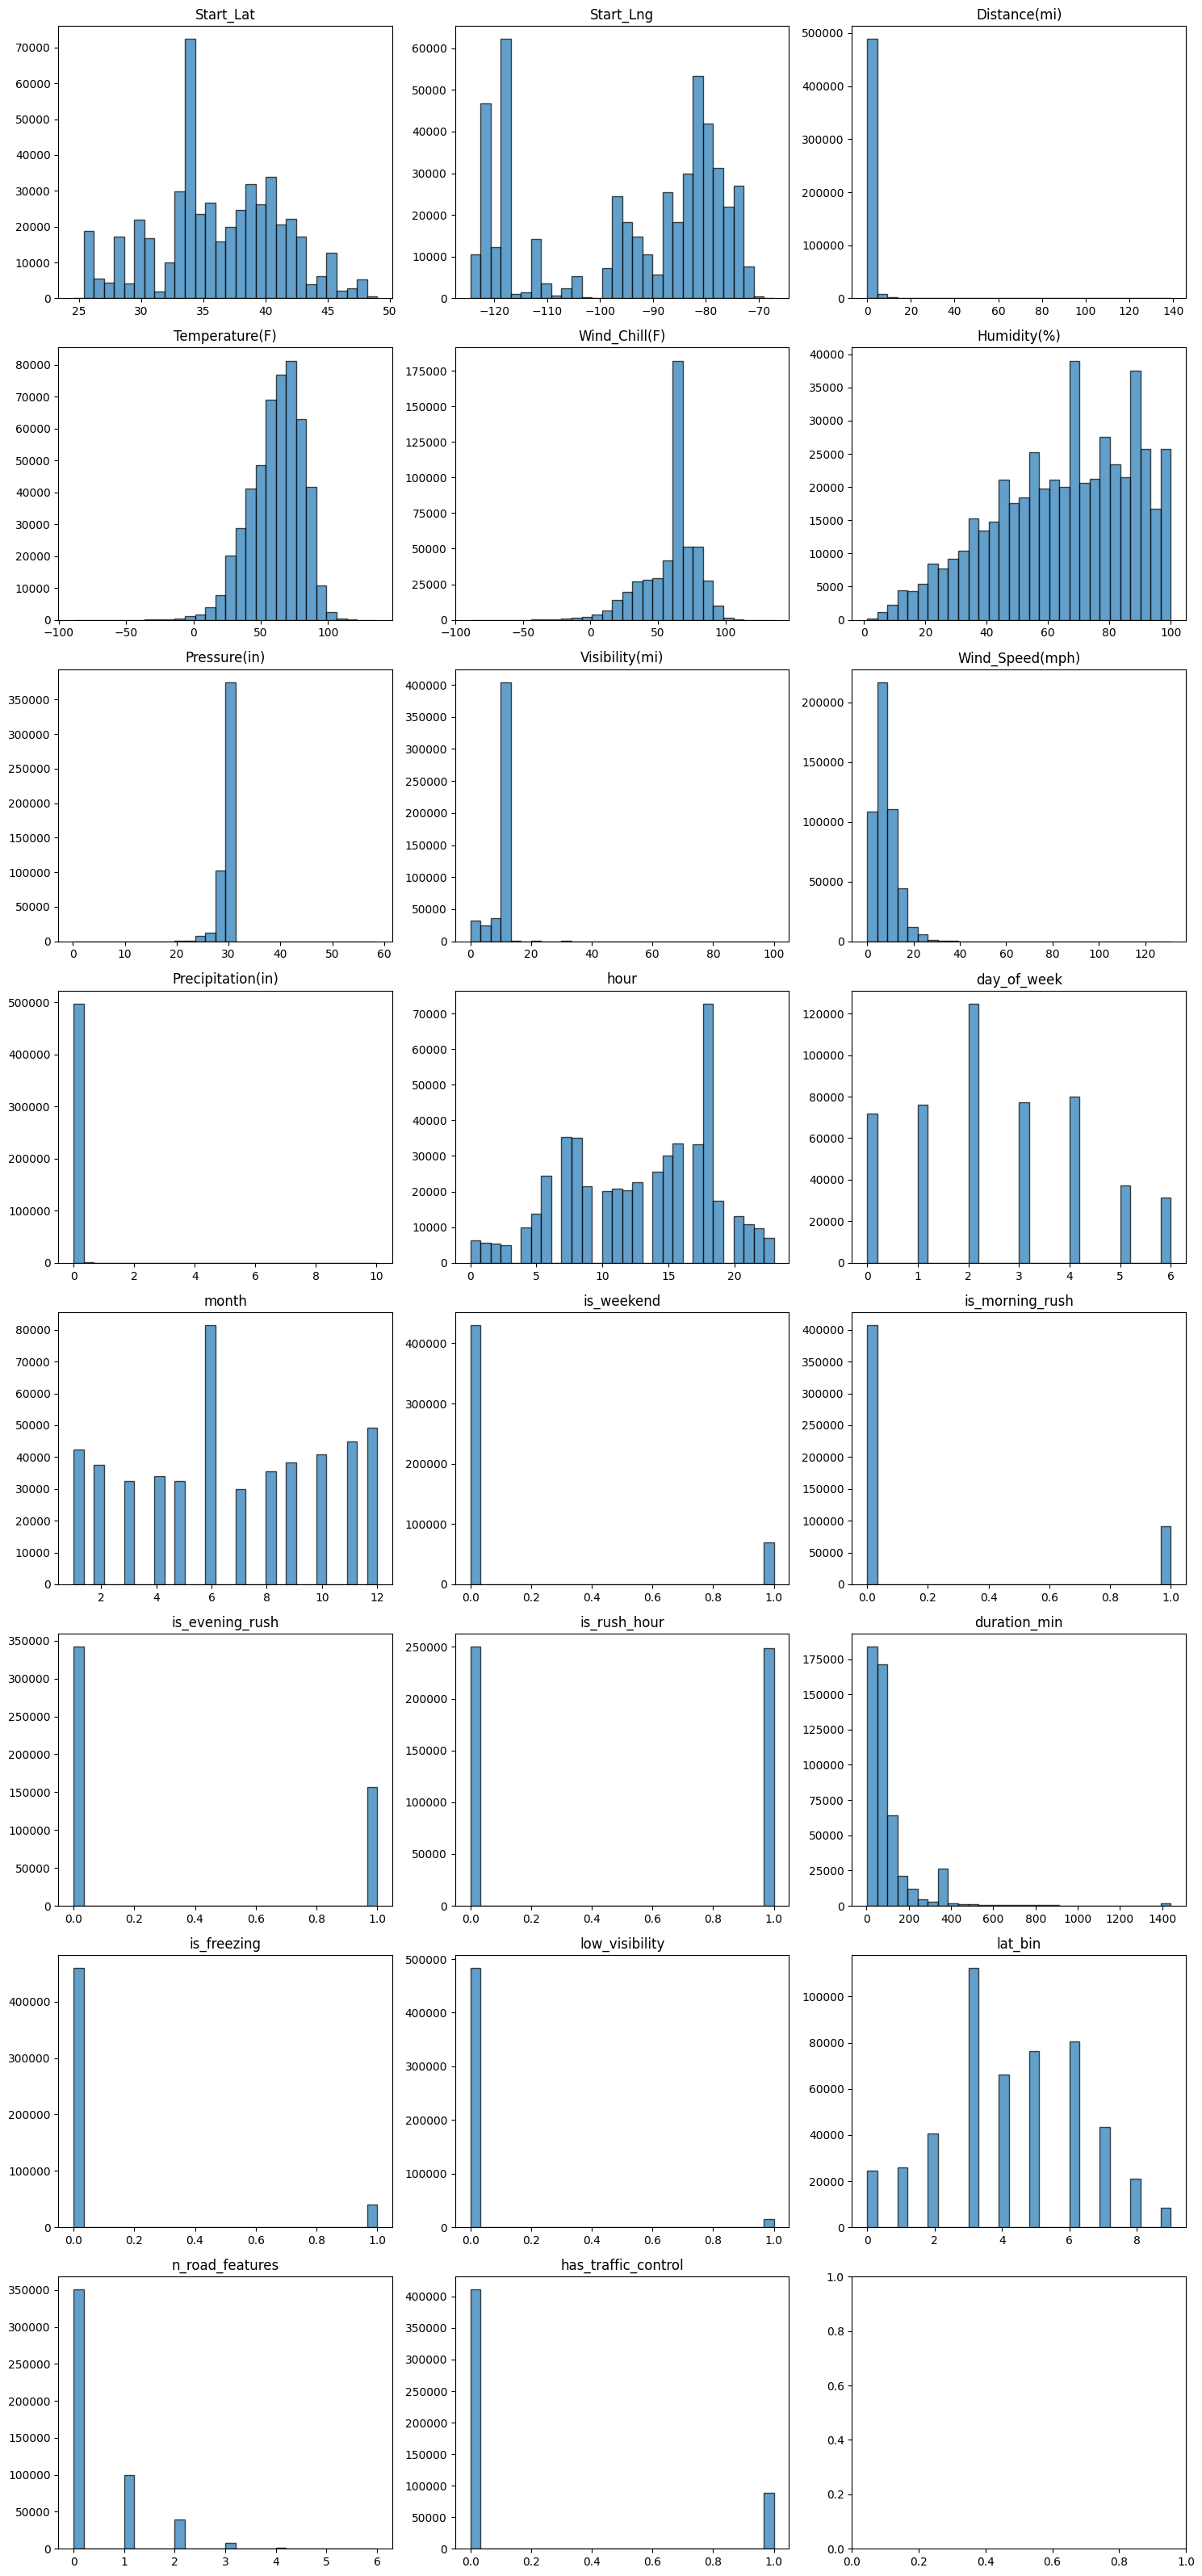

In [360]:
numerical_cols = df.select_dtypes(include=[np.number])
numerical_cols.drop(columns=['Severity', 'Target'], inplace=True)
col_names = numerical_cols.columns.tolist()
cnt = len(col_names)
print(f"There are {cnt} numberical columns. They are {col_names}")



# Distribution of numerical features
if len(col_names) > 0:
    n_cols = 3
    n_rows = (len(col_names) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

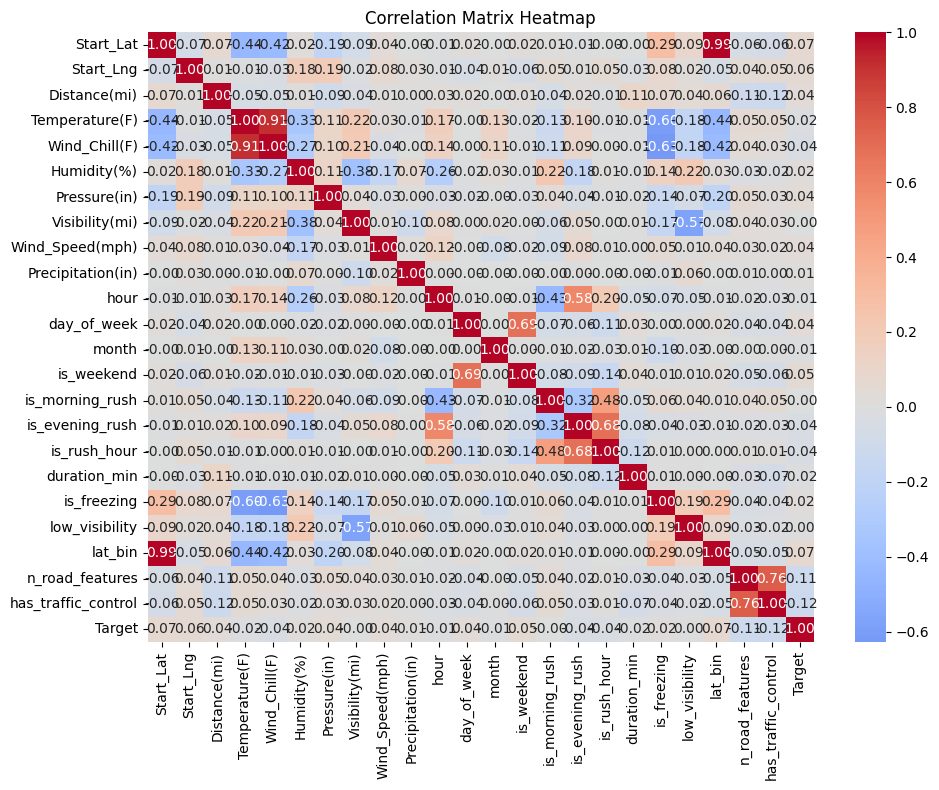

In [361]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

# YOUR CODE HERE:
df_corr = pd.concat([numerical_cols, df['Target']], axis=1)

correlation_matrix = df_corr.corr()

plt.figure(figsize=(10, 8)) # Optional: Adjust the figure size
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.tight_layout()
plt.show()

In [362]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

# YOUR CODE HERE:
print(correlation_matrix.head())

TARGET = 'Target'

correlation_matrix.drop(TARGET, axis=0, inplace=True)

                Start_Lat  Start_Lng  Distance(mi)  Temperature(F)  \
Start_Lat        1.000000  -0.067758      0.065340       -0.439494   
Start_Lng       -0.067758   1.000000      0.010431       -0.014341   
Distance(mi)     0.065340   0.010431      1.000000       -0.053021   
Temperature(F)  -0.439494  -0.014341     -0.053021        1.000000   
Wind_Chill(F)   -0.422197  -0.034418     -0.046620        0.913795   

                Wind_Chill(F)  Humidity(%)  Pressure(in)  Visibility(mi)  \
Start_Lat           -0.422197     0.022770     -0.192922       -0.086037   
Start_Lng           -0.034418     0.178908      0.190793       -0.015299   
Distance(mi)        -0.046620     0.009070     -0.088099       -0.035552   
Temperature(F)       0.913795    -0.332007      0.109631        0.216883   
Wind_Chill(F)        1.000000    -0.273925      0.103427        0.206009   

                Wind_Speed(mph)  Precipitation(in)  ...  is_morning_rush  \
Start_Lat              0.035351          -0.00

In [363]:
correlation_matrix.sort_values(by='Target', ascending=False, inplace=True)

print(correlation_matrix.iloc[:, -1:])

target_correlations = correlation_matrix.iloc[:, -1:]

                       Target
Start_Lat            0.070927
lat_bin              0.068990
Start_Lng            0.055857
is_weekend           0.052345
Pressure(in)         0.041156
day_of_week          0.038589
Wind_Speed(mph)      0.036998
Distance(mi)         0.035527
Humidity(%)          0.020922
is_freezing          0.017105
Precipitation(in)    0.008739
low_visibility       0.002885
Visibility(mi)      -0.000745
is_morning_rush     -0.004567
month               -0.006822
hour                -0.013871
duration_min        -0.017369
Temperature(F)      -0.019352
Wind_Chill(F)       -0.040213
is_evening_rush     -0.042365
is_rush_hour        -0.042882
n_road_features     -0.107157
has_traffic_control -0.115903


<Figure size 1000x600 with 0 Axes>

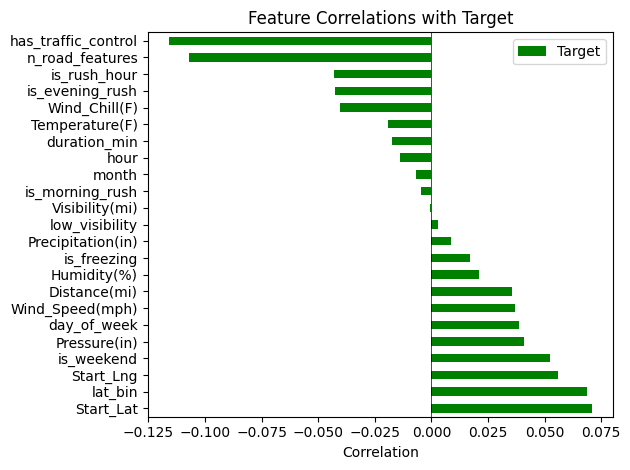

In [364]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))

colors = ['green' if c > 0 else 'red' for c in target_correlations['Target']]
#colors = np.where(target_correlations['Crop_Yield_ton_per_hectare'] >= 0, 'green', 'red')  
############# I tried several diffent methods but none can make the bar change color according to the correlation value #######################

target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

In [365]:
### final check to make sure no null values
missing_cnt = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_cnt,
    'Missing %': missing_pct
})

# 4. Filter to display only columns that have missing values (Count > 0)
#    and sort by 'Missing %' in descending order
missing_df = missing_df[missing_df['Missing Count'] > 0]
missing_df = missing_df.sort_values(by='Missing %', ascending=False)

# 5. Display the result
print(missing_df)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


In [366]:
# Encoding categorical variables
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols


cat_cols = df.select_dtypes(include=['object', 'category'])
col_names = cat_cols.columns.tolist()

for col in col_names:
    value_cnt = df[col].nunique()
    print(f"Categorical column name: {col}, number of unique values: {value_cnt} ")

Categorical column name: City, number of unique values: 9520 
Categorical column name: County, number of unique values: 1585 
Categorical column name: State, number of unique values: 49 
Categorical column name: Zipcode, number of unique values: 128054 
Categorical column name: Timezone, number of unique values: 5 
Categorical column name: Airport_Code, number of unique values: 1916 
Categorical column name: Wind_Direction, number of unique values: 24 
Categorical column name: Weather_Condition, number of unique values: 107 
Categorical column name: Sunrise_Sunset, number of unique values: 3 
Categorical column name: Civil_Twilight, number of unique values: 3 
Categorical column name: Nautical_Twilight, number of unique values: 3 
Categorical column name: Astronomical_Twilight, number of unique values: 3 
Categorical column name: weather_group, number of unique values: 7 


Encoding categorical variables

In [372]:
df.drop(columns=['Zipcode'], inplace=True)
df_ml = df.copy()

# One-hot low-cardinality cols
low_card_cols = [
    "State", "Timezone", "Wind_Direction", "Weather_Condition",
    "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight",
    "Astronomical_Twilight", "weather_group"
]
df_ml = pd.get_dummies(df_ml, columns=low_card_cols, dummy_na=True)

# Frequency encode higher-cardinality cols
for col in ["City", "County", "Airport_Code"]:
    freq_map = df_ml[col].value_counts().to_dict()
    df_ml[col] = df_ml[col].map(freq_map)


Feature Scaling of Numerical Variables will be done after Train/Test Split

In [373]:
df_clean = df_ml

In [374]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 499,290 rows, 257 columns
   (Started with 499,290 rows, 53 columns)

2. Missing values: 0

3. Duplicate rows: 0

4. Target variable 'Target':
   - Min: 1.00
   - Max: 4.00
   - Mean: 2.21

5. Data types:
   - Numerical: 28
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


In [375]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (499290, 257)

Columns (257):
['Severity', 'Start_Time', 'End_Time', 'Start_Lat', 'Start_Lng', 'Distance(mi)', 'City', 'County', 'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)', 'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Speed(mph)', 'Precipitation(in)', 'Amenity', 'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway', 'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal', 'Turning_Loop', 'Target', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_morning_rush', 'is_evening_rush', 'is_rush_hour', 'duration_min', 'is_freezing', 'low_visibility', 'lat_bin', 'n_road_features', 'has_traffic_control', 'State_al', 'State_ar', 'State_az', 'State_ca', 'State_co', 'State_ct', 'State_dc', 'State_de', 'State_fl', 'State_ga', 'State_ia', 'State_id', 'State_il', 'State_in', 'State_ks', 'State_ky', 'State_la', 'State_ma', 'State_md', 'State_me', 'State_mi', 'State_mn', 'State_mo', 'State_ms', 'State_mt', 'Stat

In [376]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv
